In [1]:
import warnings
warnings.filterwarnings('ignore')

from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file,
)

import torch
import numpy as np
import matplotlib.pyplot as plt

from flonacomldft.free_energy_computations import (
    compute_BAR_from_samples, compute_TFP_from_samples
)

## Loading the models - that is only part of them

In [2]:
# MARYLOU
project_path = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft'
isms_files = ['results_adaptive_is0_25072550/adaptive_sampling_is0_25072550.pkl', 
                'results_adaptive_is1_25072551/adaptive_sampling_is1_25072551.pkl']
mlps_files = ['results_mlp_is0_25684204/is0_mlp_dic_training_25684204.pkl',
                'results_mlp_is1_256842010/is1_mlp_dic_training_256842010.pkl',]


## ANA
# project_path = '/mnt/home/amolina/ceph/ADAPTIVE-DFT'

# isms_files = ['1-adaptive/results_2/results_adaptive_is0_25072550/adaptive_sampling_is0_25072550.pkl', 
#                 '1-adaptive/results_2/results_adaptive_is1_25072551/adaptive_sampling_is1_25072551.pkl']

# mlps_files = ['4-mlp-training/results_1/results_mlp_is0_25684204/is0_mlp_dic_training_25684204.pkl',
#                 '4-mlp-training/results_1/results_mlp_is1_256842010/is1_mlp_dic_training_256842010.pkl',]
# path_fe = project_path s+ '/5-FE-comps/0-example'


In [3]:
adaptives_dic = [load_pickle_file('/'+ f, path=project_path) for f in isms_files]
mlps_dic = [load_pickle_file('/'+ f, path=project_path) for f in mlps_files]

In [4]:
mode_labels = [0, 1]

## Loading the data

In [5]:
dic = {'md_data': '_md', 'flow_ml_samples' : 'flow_mlp',  
      'flow_dft_samples': 'flow_dft', 'flow_md_samples': 'flow_md', 
      'mcmc_dft_samples': 'mcmc_dft', 'mcmc_mlp_samples': 'mcmc_mlp'}

In [6]:
def load_samples_n_energies(kind, isomer):
    torch_tensor = load_csv_file('is{:d}_{:s}.csv'.format(isomer, dic[kind]),
                  path=project_path + '/data_free_energy')
    return torch_tensor[:, :12], torch_tensor[:, 12]

md_data - 10000 samples
flow_ml_samples - 10000 samples
flow_dft_samples - 10000 samples
flow_md_samples - 5000 samples
mcmc_dft_samples - 30000 samples
mcmc_mlp_samples - 30000 samples
md_data - 10000 samples
flow_ml_samples - 10000 samples
flow_dft_samples - 10000 samples
flow_md_samples - 5000 samples
mcmc_dft_samples - 30000 samples
mcmc_mlp_samples - 30000 samples


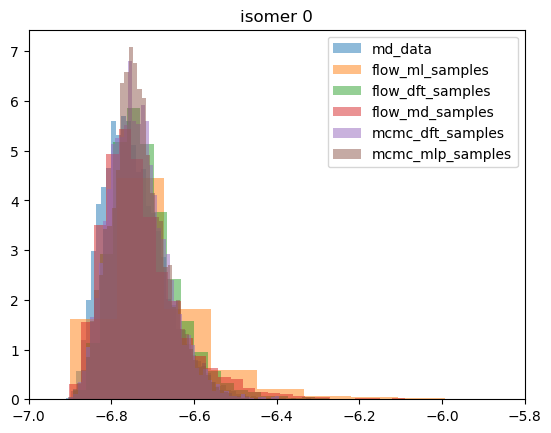

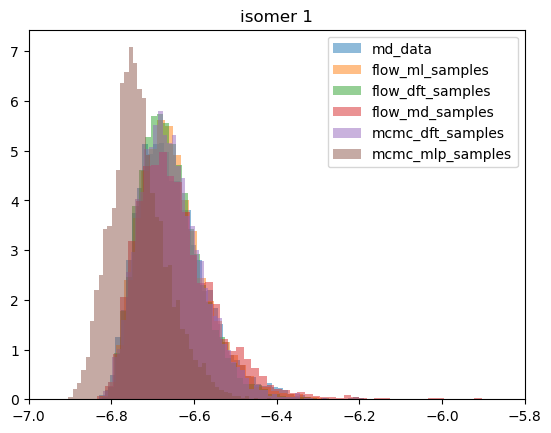

In [7]:
for isomer in mode_labels:
    plt.figure()
    plt.title('isomer {:d}'.format(isomer))
    for kind in dic.keys():
        samples, energies = load_samples_n_energies(kind, isomer)
        print('{:s} - {:d} samples'.format(kind, samples.shape[0]))
        plt.hist(energies, 50, alpha=0.5, label=kind, density=True)
        plt.xlim(-7, -5.8)
    plt.legend()

### TFP computations: 

--> We need to also pass the log prob of the flow that generated the samples

In [ ]:
logprob_prop
logprob_target
compute_TFP_from_samples(logprob_prop, logprob_target)

In [18]:
n_prop = 5

dic_results_TFPs = {}

for isomer_id in mode_labels:

    dic_results_TFPs[isomer_id] = {}
    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []

    plt.figure()
    plt.title('isomer {:d}'.format(isomer_id))
    for r,run in enumerate(adaptives_dic[isomer_id]['dict_flows_training']):
        flow = run[0]['models'][-1]
        log_ratio_0_TFPs = []
        log_err_0_TFPs = []

        for trial in range(10):
            logr_TFP_0, log_err_TFP_0 = compute_TFP(n_prop, target_log_probs[isomer_id], flow)
            log_ratio_0_TFPs.append(logr_TFP_0)
            log_err_0_TFPs.append(log_err_TFP_0)
        
        dic_results_TFPs[isomer_id][r] = (log_ratio_0_TFPs, log_err_0_TFPs)
        
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*r, log_ratio_0_TFPs, marker='x', alpha=0.2)
        plt.scatter(r, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')

        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())
    
    plt.errorbar(np.arange(len(dic_results_TFPs[isomer_id]['means'])), dic_results_TFPs[isomer_id]['means'], yerr=dic_results_TFPs[isomer_id]['stds'], fmt='o')
       

    plt.xlabel('adaptive mcmc retraining stage')
    plt.ylabel('log ratio by Targeted Free energy Perturbation (TFP)')

    # print('logr_TFP {:.3e} +/- {:.3e}'.format(np.array(log_ratio_0_TFPs).mean(), np.array(log_ratio_0_TFPs).std()))

: 

: 

: 